<div>
<a href="https://www.audiolabs-erlangen.de/fau/professor/mueller"><img src="data_layout/PCP_Teaser.png" width=100% style="float: right;" alt="PCP Teaser"></a>
</div>

# Unit 5: Visualization Using Matplotlib

<ul>
    <li><a href='#learn' style="color:#E65100;"><strong>Overview and Learning Objectives</strong></a></li>      
    <li><a href="#matplotlib" style="color:black;">Introducing Matplotlib</a></li>
    <li><a href="#background_visualization" style="color:#1B5E20;"><strong>Background:</strong> From Numbers to Visual Insight</a></li>
    <li><a href="#line_plot" style="color:black;">Line Plots and Sampled Data</a></li>
    <li><a href="#background_sampling" style="color:#1B5E20;"><strong>Background:</strong> Continuous Functions and Discrete Samples</a></li>
    <li><a href="#subplots" style="color:black;">Comparing Plotting Styles with Subplots</a></li>
    <li><a href="#vis2D" style="color:black;">Visualizing Two-Dimensional Arrays</a></li>
    <li><a href="#vis2D_details" style="color:black;">Coordinates, Display Limits, and Color Scaling</a></li>
    <li><a href='#vis3D' style="color:black;"> Plotting Surfaces (3D)</a></li>
    <li><a href='#exercise_vis1D' style="color:#006064;"><strong>Exercise 1:</strong> Plotting 1D Function</a></li>
    <li><a href='#exercise_circle' style="color:#006064;"><strong>Exercise 2:</strong> Plotting Circle</a></li>    
    <li><a href='#exercise_logaxis' style="color:#006064;"><strong>Exercise 3:</strong> Plotting with Logarithmic Axes</a></li>
    <li><a href='#exercise_plot3d' style="color:#006064;"><strong>Exercise 4:</strong> Plotting 3D Surface (sinc)</a></li>  
    <li><a href='#exercise_erlangen' style="color:#006064;"><strong>Exercise 5:</strong> Photo Manipulation (Erlangen)</a></li>      
</ul>

<a id="learn"></a>
<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<h2 style="color:#E65100; margin-top:0;">
Overview and Learning Objectives
</h2>

<p style="color:#E65100;">
Visualization helps transform numerical data into forms in which patterns, relationships, and unexpected features are easier to recognize. It is therefore an essential tool in data science, multimedia engineering, and signal processing. This unit introduces <a href="https://matplotlib.org/">Matplotlib</a>, a widely used Python library for creating scientific figures. We begin with one-dimensional curves and sampled signals, continue with two-dimensional arrays and images, and conclude with surfaces representing functions of two variables. The learning objectives are:
</p>

<ul style="color:#E65100;">
<li>Create line plots from NumPy arrays and understand how sampled values are represented visually.</li>
<li>Design informative figures using titles, axis labels, units, legends, grids, colors, markers, and appropriate axis limits.</li>
<li>Arrange several plots in a single figure using subplots.</li>
<li>Visualize two-dimensional arrays as color-coded images and interpret parameters such as the colormap, origin, aspect ratio, and coordinate extent.</li>
<li>Construct coordinate grids and visualize functions of two variables as color-coded images or three-dimensional surfaces.</li>
<li>Load, display, manipulate, and save digital images represented as NumPy arrays.</li>
</ul>

<p style="color:#E65100;">
The unit includes five hands-on exercises:
</p>

<ul style="color:#E65100;">
<li><a href="#exercise_vis1D">Exercise 1</a>: Visualize a sampled sinusoid using line, stem, step, and bar plots.</li>
<li><a href="#exercise_circle">Exercise 2</a>: Construct a circle from sampled sine and cosine values and investigate the effect of the sampling rate.</li>
<li><a href="#exercise_logaxis">Exercise 3</a>: Compare linear and logarithmic axis scales.</li>
<li><a href="#exercise_plot3d">Exercise 4</a>: Construct a two-dimensional grid and visualize a function as a surface.</li>
<li><a href="#exercise_erlangen">Exercise 5</a>: Load and creatively manipulate a photograph represented as a NumPy array.</li>
</ul>

<p style="color:#E65100;">
Visualizations will accompany many later units, particularly those dealing with complex exponentials, sampled signals, and Fourier analysis. For further examples, see the <a href="https://matplotlib.org/stable/gallery/index.html">Matplotlib gallery</a>, which includes executable plotting examples, and the <a href="https://www.audiolabs-erlangen.de/FMP">FMP Notebooks</a>, which contain numerous visualizations from audio and music processing.
</p>
</div>

In [1]:
# --- Core scientific stack ---
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Custom utilities (Unit 5) ---
from libpcp.unit05 import (
    exercise_vis1D,
    exercise_circle,
    exercise_logaxis,
    exercise_plot3d,
    exercise_erlangen
)

# --- Vectorized figures and font size settings ---
%config InlineBackend.figure_formats = ['svg']
plt.rcParams.update({'font.size': 8, 'axes.titlesize': 9})

<a id="matplotlib"></a>
## Introducing Matplotlib

[Matplotlib](https://matplotlib.org/) is a widely used Python library for creating scientific visualizations. It can produce line plots, scatter plots, images, surface plots, and many other kinds of figures. These figures can be displayed interactively in a Jupyter notebook or saved in formats such as PNG, SVG, and PDF. This unit uses the module [`matplotlib.pyplot`](https://matplotlib.org/stable/api/pyplot_summary.html), which provides the functions needed to create and modify figures. Following the usual convention, we imported it earlier using the abbreviation `plt`. We also imported NumPy as `np` for constructing and processing the numerical data to be visualized.

Python provides several ways to explore the available plotting functions. The function `dir(plt)` returns a list containing the names available in the module, while `help()` displays documentation for a selected function. For example, `help(plt.plot)` describes the function used to create line plots. Within a Jupyter notebook, the question-mark syntax `plt.plot?` provides similar information. Since Matplotlib contains many functions and the resulting documentation may be long, we do not display it here. In practice, the searchable [Matplotlib documentation](https://matplotlib.org/stable/) and its [gallery of examples](https://matplotlib.org/stable/gallery/index.html) are particularly useful when looking for a suitable plot or plotting option.

<a id="background_visualization"></a>
<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">

<h2 style="color:#1B5E20; margin-top:0;">
Background: From Numbers to Visual Insight
</h2>

<p style="color:#1B5E20;">
The familiar saying that <strong>a picture is worth a thousand words</strong> is particularly appropriate in data analysis and signal processing. A signal may contain millions of samples, and an image may contain millions of pixel values. Although the numbers contain the information, inspecting them individually rarely reveals much. A suitable figure can make important structures visible at a glance. Different numerical objects naturally suggest different visual representations. A <strong>line plot</strong> may reveal silence, oscillations, impulses, or changes in the amplitude of a signal. An <strong>image</strong> maps values to spatial positions and colors, making shapes, edges, and textures visible. A <strong>surface</strong> can show how a quantity depends on two variables. When the data consist of separate items, a <strong>scatter plot</strong> represents each item as a point and may reveal groups, trends, outliers, or relationships between measured properties.
</p>

<div style="
  float:right;
  width:200px;
  max-width:45%;
  margin-left:20px;
  margin-bottom:10px;
">
<img src="data/PCP_fig_mandelbrot.png"
     style="display:block; width:100%; height:auto;"
     alt="Visualization of the Mandelbrot set">
</div>

<p style="color:#1B5E20;">
Visualization can also make abstract mathematical objects accessible. A set of numbers, for example, may be represented by marking the positions of its elements in a coordinate system. A particularly striking example is the <a href="https://en.wikipedia.org/wiki/Mandelbrot_set"><strong>Mandelbrot set</strong></a>, a subset of the complex plane defined by repeatedly applying a simple mathematical rule. Each point in the image corresponds to a complex number, and its color indicates the behavior of the associated iteration. The exact set contains infinitely fine detail and cannot be drawn completely. A computer instead examines a finite grid of complex numbers and performs a limited number of iterations. The resulting image is only an approximation, yet it reveals an elaborate fractal boundary in which increasingly fine structures appear under magnification. We will return to this example in <a href="PCP_06_complex.html">Unit 6</a>, where a simple numerical procedure will produce this surprisingly intricate picture.
</p>

<p style="color:#1B5E20; margin-bottom:0;">
Visualizations can accompany every stage of an analysis: the original signal or image, an intermediate transformation, an extracted feature, or the final result. Different figures may also reveal different aspects of the same data. A waveform emphasizes change over time, a histogram shows the distribution of values, and a frequency-domain representation obtained using the discrete Fourier transform exposes oscillatory structure. <strong>A good scientific figure is therefore more than decoration</strong>. It helps us explore data, check calculations, discover unexpected behavior, and communicate results. Matplotlib provides the tools, but choosing what to show remains our responsibility. <strong>A picture may be worth a thousand words, but only when it is the right picture</strong>.
</p>

<div style="clear:both;"></div>
</div>

<a id="line_plot"></a>

## Line Plots and Sampled Data

We begin with one of the most basic and widely used visualizations: the **line plot**. A line plot represents pairs of numerical values as points in a coordinate system and connects neighboring points with line segments. It is particularly useful for showing how one quantity changes with another, such as the amplitude of a signal over time or the value of a mathematical function over its input variable.

To construct a line plot, Matplotlib needs two arrays of equal length. The first contains the horizontal coordinates, and the second contains the corresponding vertical values. In the following example, we use sampled values of the sine and cosine functions over the interval from $-\pi$ to $\pi$. The array `t` contains 256 equally spaced angles, including both endpoints, while `f_cos` and `f_sin` contain the corresponding function values.

The function `plt.figure()` creates a new figure. Its size is specified in inches using `figsize=(width, height)`, while `layout='tight'` automatically adjusts the spacing around the plotting area. Each call to `plt.plot()` adds a line to the current figure. Matplotlib selects suitable colors and axis limits automatically:

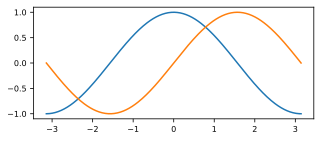

In [2]:
# Compute the sampled function values
t = np.linspace(-np.pi, np.pi, 256, endpoint=True)
f_cos = np.cos(t)
f_sin = np.sin(t)

# Plot both functions in the same figure
plt.figure(figsize=(4.5, 2.0), layout='tight')
plt.plot(t, f_cos)
plt.plot(t, f_sin)

For every index `n`, the two calls plot the pairs `(t[n], f_cos[n])` and `(t[n], f_sin[n])`. Matplotlib connects neighboring points with straight segments, which appear smooth because the 256 sampling positions are closely spaced. Jupyter may also display output such as `[<matplotlib.lines.Line2D at 0x...>]`. This is not an error but a representation of the line object returned by `plt.plot()`. Adding a semicolon to the final command, as in `plt.plot(t, f_sin);`, suppresses this textual output without affecting the figure.

The default settings provide a quick view of the data. A scientific figure, however, should give readers enough information to understand what is shown without inspecting the plotting code. The next example uses the same data and introduces several important ways to control the figure:

* `color`, `linewidth`, and `linestyle` control the appearance of a line.
* `label` names a line, while `plt.legend()` displays the assigned names.
* `plt.title()`, `plt.xlabel()`, and `plt.ylabel()` describe the figure and its axes.
* `plt.xlim()` and `plt.ylim()` determine the visible ranges.
* `plt.xticks()` and `plt.yticks()` control the tick positions and labels.
* `plt.savefig()` saves the completed figure to a file.

Matplotlib provides many additional formatting options, which can be explored in the documentation for [`plt.plot()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html) and the other plotting functions when needed. In the following example, meaningful tick labels, descriptive axis labels, a legend, and carefully selected visual properties make the figure easier to interpret and help communicate its main content clearly:


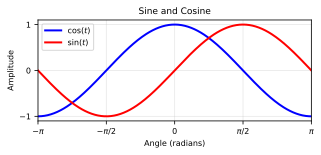

In [3]:
plt.figure(figsize=(4.5, 2.2), layout='tight')

plt.plot(t, f_cos, color='blue', linewidth=2, label=r'$\cos(t)$')
plt.plot(t, f_sin, color='red', linewidth=2, label=r'$\sin(t)$')

plt.title('Sine and Cosine')
plt.xlabel('Angle (radians)')
plt.ylabel('Amplitude')
plt.xlim(-np.pi, np.pi)
plt.ylim(-1.1, 1.1)
plt.xticks(
    [-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
    [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'],
)
plt.yticks([-1, 0, 1])
plt.grid(alpha=0.3)
plt.legend(loc='upper left')

# The output directory must already exist
output_path = os.path.join('output', 'Figure_CosSin.png')
plt.savefig(output_path)

<a id="background_sampling"></a>
<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">

<h2 style="color:#1B5E20; margin-top:0;">
Background: Continuous Functions and Discrete Samples
</h2>

<p style="color:#1B5E20;">
The mathematical function $t\mapsto\sin(t)$ is defined for every real number $t\in\mathbb{R}$. A NumPy array, in contrast, contains only a <strong>finite collection of function values</strong>. In the preceding example, the arrays contain the values of the sine and cosine functions at 256 selected positions. This finite collection is all that Matplotlib receives. Nevertheless, the resulting figure appears to show smooth, continuous curves. This illustrates an important distinction between <strong>what the data contain</strong> and <strong>what the visualization appears to show</strong>. The function <code>plt.plot()</code> connects neighboring points with straight line segments, thereby creating a <strong>piecewise-linear interpolation</strong> for visual purposes.
</p>

<p style="color:#1B5E20;">
The connecting lines make the overall development easier to recognize, but they do not add new measurements or prove what happened between the available points. With closely spaced points, the result may closely resemble the underlying function. With fewer points, it may appear angular, hide rapid variations, or suggest a shape that was never observed. <strong>Markers</strong> and <strong>stem plots</strong> make the discrete values more visible, while lines emphasize their overall development. The most suitable plotting style depends on the application, the intended message, and the desired visual appearance.
</p>

<p style="color:#1B5E20; margin-bottom:0;">
We will return to this distinction in <a href="PCP_08_signal.html#sampling">Unit 8</a>, where we study sampling and ask when discrete values preserve the behavior of a continuous signal. Until then, remember: <strong>Matplotlib may draw a smooth story between the points, but the data supplied only the dots.</strong>
</p>
</div>

<a id="subplots"></a>
## Comparing Plotting Styles with Subplots

Several curves can be drawn in the same coordinate system when they should be compared directly. In other situations, separate plotting areas make different representations easier to inspect. These panels are commonly called **subplots**, and a single figure may contain several of them arranged in rows and columns. The function `plt.subplot(num_rows, num_columns, index)` creates or selects one panel. The panels are numbered from left to right and top to bottom, beginning with `1`. For example, `plt.subplot(2, 1, 1)` selects the upper panel in an arrangement with two rows and one column, while `plt.subplot(2, 1, 2)` selects the lower panel. All subsequent plotting commands affect the currently selected subplot until another one is selected.

Subplots are useful for comparing related quantities while keeping their graphical representations separate. When a comparison depends on visual height or position, the panels should use the same axis limits so that differences in appearance reflect the data rather than different scales. In the following example, two vertically arranged subplots show the same sampled sine function in different ways. We deliberately use only 17 points so that the individual sampling positions remain visible:

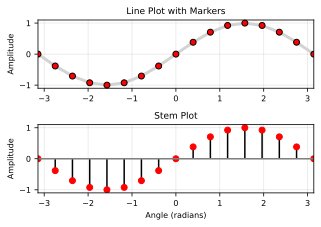

In [4]:
t_sparse = np.linspace(-np.pi, np.pi, 17)
f_sparse = np.sin(t_sparse)

plt.figure(figsize=(4.5, 3.2), layout='tight')

plt.subplot(2, 1, 1)
plt.plot(t_sparse, f_sparse, color='lightgray', linewidth=3,
         marker='o', markerfacecolor='red', markeredgecolor='black')
plt.title('Line Plot with Markers')
plt.ylabel('Amplitude')
plt.xlim(-np.pi, np.pi)
plt.ylim(-1.1, 1.1)
plt.grid(alpha=0.3)

plt.subplot(2, 1, 2)
plt.stem(t_sparse, f_sparse, linefmt='black', markerfmt='ro', basefmt='gray')
plt.title('Stem Plot')
plt.xlabel('Angle (radians)')
plt.ylabel('Amplitude')
plt.xlim(-np.pi, np.pi)
plt.ylim(-1.1, 1.1)
plt.grid(alpha=0.3)

Both panels represent exactly the same numerical values, but they emphasize different aspects of the data. The line plot highlights the overall shape while retaining the sampling positions through markers. The stem plot emphasizes the individual values and their relation to a common baseline, making it especially useful for discrete signals.

Matplotlib provides many other plot types for particular purposes. For example, `plt.scatter()` displays unrelated points, `plt.step()` holds each value until the next position, `plt.bar()` compares quantities using bars, `plt.hist()` visualizes a distribution, and `plt.errorbar()` adds uncertainty information. We will introduce such representations when they serve a specific purpose rather than attempting to memorize every plotting function here. An overview with executable examples is available in the official [Matplotlib plot types](https://matplotlib.org/stable/plot_types/index.html) documentation.

<a id="vis2D"></a>
## Visualizing Two-Dimensional Arrays

A line plot arranges values along a one-dimensional coordinate axis. Many numerical objects, however, are naturally organized in two dimensions. A digital image contains values at horizontal and vertical pixel positions, a table contains entries arranged in rows and columns, and a function of two variables may be evaluated on a rectangular grid. Matplotlib can visualize a two-dimensional NumPy array by representing each entry as a colored cell. The position of the cell corresponds to the row and column of the array, while its color represents the numerical value. The function `plt.imshow()` creates this color-coded representation, and `plt.colorbar()` adds a scale showing how the colors correspond to numerical values.

We begin with a small $5\times 5$ array `A` containing the integers from $0$ to $23$. Each colored square will represent one array entry. The horizontal axis shows the column index, while the vertical axis shows the row index. By default, row index `0` appears at the top, following the usual convention for displaying digital images.

The argument `cmap` selects the **colormap** used to translate numerical values into colors. In the selected colormap, smaller and larger values appear in different colors, whose numerical meaning can be read from the **colorbar**. The argument `interpolation='nearest'` keeps the individual cells clearly separated instead of visually smoothing the transitions between them. The following example illustrates these relationships between values, positions, and colors:

Array A:
[[ 0  1  2  3  4  5  6  7]
 [ 8  9 10 11 12 13 14 15]
 [16 17 18 19 20 21 22 23]]


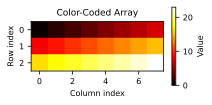

In [5]:
A = np.arange(24).reshape(3, 8)
print('Array A:', A, sep='\n')

plt.figure(figsize=(3.0, 1.5), layout='tight')
plt.imshow(A, cmap='hot', interpolation='nearest')
plt.colorbar(label='Value')
plt.title('Color-Coded Array')
plt.xlabel('Column index')
plt.ylabel('Row index');

The visualization does not change the array itself; it only determines how the array entries are displayed. Several parameters influence this visual representation:

* `cmap` selects the colormap used to represent the numerical values.
* `origin` determines whether the first row appears at the top or bottom.
* `aspect` controls the geometric proportions of the displayed cells. The default value `'equal'` keeps the cells square, while `'auto'` stretches the image to fill the available plotting area.

The appropriate settings depend on the meaning of the array. Digital images are commonly displayed with the first row at the top, while data associated with a Cartesian coordinate system are often easier to interpret with the origin at the lower left. The following three panels visualize exactly the same numerical array using different settings. Only its visual representation changes, reminding us that the appearance of a figure depends not only on the data but also on the selected plotting parameters:

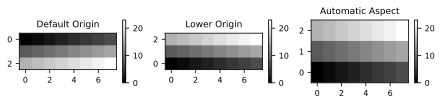

In [6]:
A = np.arange(24).reshape(3, 8)
plt.figure(figsize=(6.2, 1.5), layout='tight')

plt.subplot(1, 3, 1)
plt.imshow(A, cmap='grey', interpolation='nearest')
plt.colorbar()
plt.title('Default Origin')

plt.subplot(1, 3, 2)
plt.imshow(A, cmap='grey', origin='lower', interpolation='nearest')
plt.colorbar()
plt.title('Lower Origin')

plt.subplot(1, 3, 3)
plt.imshow(A, cmap='grey', origin='lower',
           aspect='auto', interpolation='nearest')
plt.colorbar()
plt.title('Automatic Aspect');

<a id="vis2D_details"></a>

## Coordinates, Display Limits, and Color Scaling

Displaying a two-dimensional array involves two separate mappings. The position of each array entry must be mapped to a location in the figure, and its numerical value must be mapped to a color. Matplotlib provides different parameters for controlling these aspects:

* `extent` assigns coordinate ranges to the displayed array.
* `plt.xlim()` and `plt.ylim()` select the visible coordinate region.
* `vmin` and `vmax` determine the numerical range represented by the colormap.

We begin with the spatial coordinates. So far, the axes have shown row and column indices. In many applications, however, these indices correspond to meaningful quantities such as time, frequency, distance, or spatial position. The argument `extent=[left, right, lower, upper]` assigns coordinate ranges to the horizontal and vertical axes without changing the underlying array.

For a more informative example, we evaluate the function $f(x,y)=0.9\sin(3x)\cos(3y)\exp(-y^2)$ on a rectangular grid with $x\in[-2,3]$ and $y\in[-1,2]$. The function `np.meshgrid()` constructs the coordinate matrices `X` and `Y` required for this calculation; we will examine this construction more closely in the section on surface plots. We additionally set one array entry to $1.3$, creating a clearly recognizable outlier that will help us locate the selected region when zooming into the figure. The resulting array `A_wave` has shape `(31, 51)`. The first panel displays it using array indices, with columns from `0` to `50` and rows from `0` to `30`. In the second panel, `extent` maps the same entries to horizontal coordinates from `-2` to `3` and vertical coordinates from `-1` to `2`. The values and shape of the array remain unchanged; only the coordinates used to display them are different:


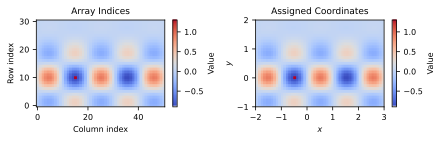

In [7]:
x = np.linspace(-2, 3, 51)
y = np.linspace(-1, 2, 31)
X, Y = np.meshgrid(x, y)
A_wave = 0.9 * np.sin(3 * X) * np.cos(3 * Y) * np.exp(-Y**2)
A_wave[10, 15] = 1.3
coordinate_extent = [-2, 3, -1, 2]

plt.figure(figsize=(6.2, 2.0), layout='tight')

plt.subplot(1, 2, 1)
plt.imshow(A_wave, cmap='coolwarm', origin='lower',
           aspect='auto', interpolation='nearest')
plt.colorbar(label='Value')
plt.title('Array Indices')
plt.xlabel('Column index')
plt.ylabel('Row index')

plt.subplot(1, 2, 2)
plt.imshow(A_wave, cmap='coolwarm', origin='lower', aspect='auto',
           extent=coordinate_extent, interpolation='nearest')
plt.colorbar(label='Value')
plt.title('Assigned Coordinates')
plt.xlabel('$x$')
plt.ylabel('$y$');

The functions `plt.xlim()` and `plt.ylim()` select a smaller part of the displayed coordinate region, much like zooming into a figure. Their arguments always refer to the coordinates shown on the corresponding axes. When `extent` is specified, these are the assigned coordinates, such as $x\in[-2,3]$ and $y\in[-1,2]$ in this example. Without `extent`, the limits refer to column and row indices instead. In either case, only the visible region changes; the underlying array and its coordinate mapping remain unchanged:

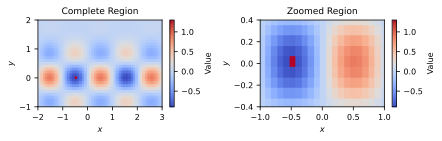

In [8]:
plt.figure(figsize=(6.2, 2.0), layout='tight')

plt.subplot(1, 2, 1)
plt.imshow(A_wave, cmap='coolwarm', origin='lower', aspect='auto',
           extent=coordinate_extent, interpolation='nearest')
plt.colorbar(label='Value')
plt.title('Complete Region')
plt.xlabel('$x$')
plt.ylabel('$y$')

plt.subplot(1, 2, 2)
plt.imshow(A_wave, cmap='coolwarm', origin='lower', aspect='auto',
           extent=coordinate_extent, interpolation='nearest')
plt.colorbar(label='Value')
plt.xlim(-1, 1)
plt.ylim(-0.4, 0.4)
plt.title('Zoomed Region')
plt.xlabel('$x$')
plt.ylabel('$y$');

The coordinate limits determine **where we look**, while the color limits determine **how the numerical values appear**. By default, Matplotlib maps the smallest and largest values of the complete array to the two ends of the colormap. An unusually large or small value may therefore reduce the visible contrast among the remaining values. The parameters `vmin` and `vmax` explicitly set the numerical color range. Values outside this range receive its endpoint colors. The following panels compare automatic scaling with a symmetric range from `-0.5` to `0.5`:

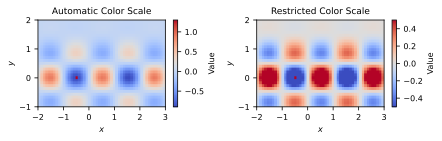

In [9]:
plt.figure(figsize=(6.2, 2.0), layout='tight')

plt.subplot(1, 2, 1)
plt.imshow(A_wave, cmap='coolwarm', origin='lower', aspect='auto',
           extent=coordinate_extent, interpolation='nearest')
plt.colorbar(label='Value')
plt.title('Automatic Color Scale')
plt.xlabel('$x$')
plt.ylabel('$y$')

plt.subplot(1, 2, 2)
plt.imshow(A_wave, cmap='coolwarm', origin='lower', aspect='auto',
           extent=coordinate_extent, interpolation='nearest',
           vmin=-0.5, vmax=0.5)
plt.colorbar(label='Value')
plt.title('Restricted Color Scale')
plt.xlabel('$x$')
plt.ylabel('$y$');

In the first panel, the complete value range of `A_wave`, including the outlier, determines the color scale. In the second, the symmetric limits place zero at the center of the diverging colormap and increase the visible contrast among values between $-0.5$ and $0.5$. The outlier, as well as every other value outside this interval, is represented using one of the endpoint colors. This improves contrast within the selected range but hides differences between values beyond its limits; the underlying array itself remains unchanged. When several arrays are compared, common values for `vmin` and `vmax` ensure that the same color represents the same numerical value in every panel. Otherwise, two identical colors may quietly mean two different things.

<a id="vis3D"></a>

## Three-Dimensional Surface Plots

A two-dimensional array can contain sampled values of a function with two input variables. Such values may be represented by colors, as in an image, or by heights above a coordinate plane, producing a **surface plot**.

Consider the function

$$
f(x,y)=\sin(3x)\cos(3y)\exp(-y^2).
$$

To evaluate this function on a rectangular region, we first choose one-dimensional coordinate arrays `x` and `y`. The function `np.meshgrid()` then constructs two coordinate matrices `X` and `Y`. Every entry `X[m, n]` contains an $x$-coordinate, while the corresponding entry `Y[m, n]` contains a $y$-coordinate. Evaluating the formula with these matrices produces a third matrix `Z` containing the function values:

<a id='vis3D'></a> 
## Plotting Surfaces (3D)

The library `matplotlib` also offers various possibilities for creating 3D plots. Technically one needs to create a figure and add a new axis of type `Axes3D` to it. For details, we refer to the [mplot3d tutorial](https://matplotlib.org/mpl_toolkits/mplot3d/tutorial.html) and consider only one example. Based on the previously visualized matrix, the following plot shows a 3D representation of the same data.

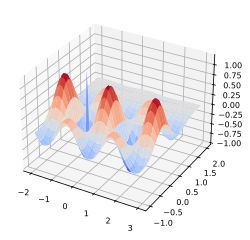

In [10]:
X, Y = np.meshgrid(np.arange(-2, 3.1, 0.1), np.arange(-1, 2.1, 0.1))
A = np.sin(X*3) * np.cos(Y*3) * np.exp(-Y**2)
A[10, 15] = 1.2

fig = plt.figure(figsize=(3.5, 3.5), layout='tight')
ax = fig.add_subplot(projection='3d')
ax.plot_surface(X, Y, A, cmap='coolwarm')

<a id='exercise_vis1D'></a> 
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064; display: block; break-after: avoid; page-break-after: avoid;">Exercise 1: Plotting 1D Function</strong>
<ul style="color:#006064;">
    <li> Create a vector <code>t</code> that represents a discrete time axis (given in seconds) covering the interval $[0, 1]$ sampled with a sampling rate of $F_\mathrm{s}=100~\mathrm{Hz}$. (In other words <code>t[0]=0, t[1]=0.01, ...,t[100]=1 </code>.)</li>
    <li> Plot the graph of the sinusoid $x(t) = \mathrm{sin}(2\pi \omega t)$ using frequency $\omega = 5~\mathrm{Hz}$ over the time points specified by <code>t</code>.</li>
    <li> Label the horizontal axis (<code>Time (seconds)</code>) and vertical axis (<code>Amplitude</code>) and add a title. Display grid lines.</li>
    <li>Modify the appearance of the sinusoid by varying the arguments <code>color</code>, <code>linewidth</code>, <code>linestyle</code>, and <code>marker</code> in the <code>plt.plot</code> function. You can find a table of all possible arguments <a href="https://matplotlib.org/api/_as_gen/matplotlib.pyplot.plot.html">here</a>.
    <li>Set the limits of the horizontal axis such that only one period of the sinusoid is shown.</li>
    <li>Use a figure with three subplots and plot one period of the sinusoid using the Python functions <code>plt.stem</code>, <code>plt.step</code>, and <code>plt.bar</code>. Explain the differences.
</ul>
</div>

In [11]:
# Your Solution

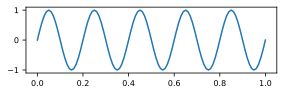

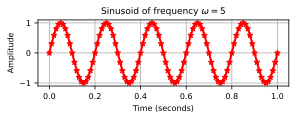

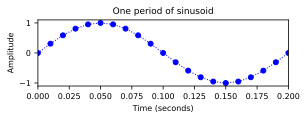

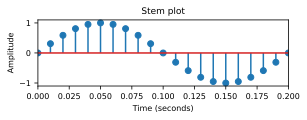

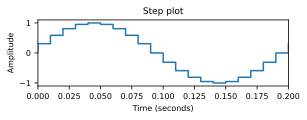

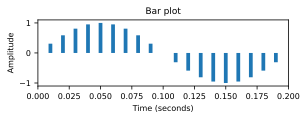

In [12]:
exercise_vis1D()

<a id='exercise_circle'></a> 
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064; display: block; break-after: avoid; page-break-after: avoid;">Exercise 2: Plotting Circle</strong>
<ul style="color:#006064;">
    <li> Create a vector <code>t</code> that represents a discrete time axis (given in seconds) covering the interval $[0, 1]$ sampled with a sampling rate of $F_\mathrm{s}$ given in $\mathrm{Hz}$. (See <a href='#ex:vis1D'>Exercise 1: Plotting 1D Function</a>.)</li>        
    <li> Specify two functions $f_1(t)$ and $f_2(t)$ such that one obtains a unit circle when plotting the values $f_1(t)$ against the values of $f_2(t)$ using <code>np.plot</code>.</li>
    <li>Write a function <code>plot_circle</code> that plots a circle in this way with an argument that specifies the sampling rate $F_\mathrm{s}$.</li>
    <li>Apply the function using different sampling rates $F_\mathrm{s}\in\{4,8,16,32\}$</li> </ul>   
</div>

In [13]:
# Your Solution

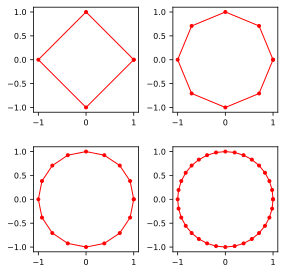

In [14]:
exercise_circle()

<a id='exercise_logaxis'></a> 
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064; display: block; break-after: avoid; page-break-after: avoid;">Exercise 3: Plotting with Logarithmic Axes</strong>
<p style="color:#006064;">
Consider functions $f(x) = e^x$, $g(x) = x$, and $h(x)=1.1 + \mathrm{sin}(10\cdot x)$ for $x\in\mathbb{R}$. For a given sampling rate <code>Fs</code>, let  <code>x = np.arange(1/Fs, 10+1/Fs, 1/Fs)</code> be the discretized axis covering the interval <code>[1/Fs, 10]</code>. Furthermore, let <code>f</code>, <code>g</code>, and <code>h</code> be the vectors obtained by evaluating $f$, $g$, and $h$ on <code>x</code>, respectively. Using the sampling rate <code>Fs=100</code>, plot the graphs for all three functions in the same figure (using different colors). Switch on the grid-line option (using <code>plt.grid()</code>). Besides using <code>plt.plot</code>, also use the functions <code>plt.semilogy</code>, <code>plt.semilogx</code>, <code>plt.loglog</code>. What do you observe?
</p>
</div>

In [15]:
# Your Solution

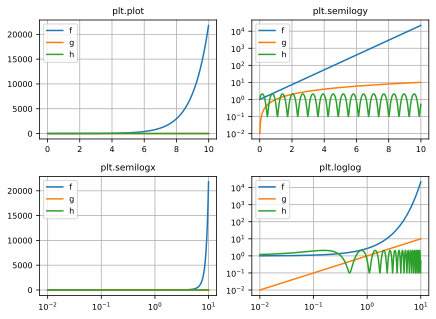

In [16]:
exercise_logaxis()

<a id='exercise_plot3d'></a> 
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064; display: block; break-after: avoid; page-break-after: avoid;">Exercise 4: Plotting 3D Surface (sinc)</strong>
<p style="color:#006064;">
The $\mathrm{sinc}$-function (<code>np.sinc</code>) is defined by $\mathrm{sinc}(t) := \frac{\mathrm{sin}(\pi t)}{\pi t}$ for $t\in\mathbb{R}$ and $\mathrm{sinc}(0):=1$. In the following, we want to visualize the surface of the function $f(x,y) = \mathrm{sinc}(3x) + \mathrm{sinc}(3y)$ for variables $x, y \in [-1,\, 1]$. To this end, we represent the area $[-1,\, 1]$ by an equidistant 2D-grid with a resolution specified by parameters $\Delta x = \Delta y = 0.01$. The grid points are represented by two equal-sized matrices $\mathbf{X}$ and $\mathbf{Y}$, where $\mathbf{X}$ contains all $x$-coordinates and $\mathbf{Y}$ all $y$-coordinates:
\begin{align*}
\mathbf{X} & = 
\begin{bmatrix}
	-1 & -0.99 & -0.98 & \cdots &  & 0.98 & 0.99 & 1\cr
	-1 & -0.99 & -0.98 & \cdots &  & 0.98 & 0.99 & 1\cr
	\vdots & \vdots & \vdots & \vdots & \vdots & \vdots & \vdots &
						\vdots\cr
	-1 & -0.99 & -0.98 & \cdots &  & 0.98 & 0.99 & 1\cr
	-1 & -0.99 & -0.98 & \cdots &  & 0.98 & 0.99 & 1\cr
\end{bmatrix}
\\[1mm]
\mathbf{Y} & =
\begin{bmatrix}
	-1 & -1 & -1 & \cdots &  & -1 & -1 & -1\cr
	-0.99 & -0.99 & -0.99 & \cdots &  & -0.99 & -0.99 & -0.99\cr
	\vdots & \vdots & \vdots & \vdots & \vdots & \vdots & \vdots &
						\vdots\cr
	0.99 & 0.99 & 0.99 & \cdots &  & 0.99 & 0.99 & 0.99\cr
	1 & 1 & 1 & \cdots &  & 1 & 1 & 1\cr
\end{bmatrix}
\end{align*}
</p>

<ul style="color:#006064;">
    <li> Create the matrices <code>X</code> and <code>Y</code> that have data points with a spacing of $\Delta x = \Delta y = 0.01$ using the function <code>np.meshgrid</code>.</li>
    <li> Evaluate the function $f(x,y)$ on the grid defined by <code>X</code> and <code>Y</code>.</li>
    <li> Plot the 3D-surface using the function <code>plot_surface</code>. </li>
    <!--Get yourself familiar with the interactive environment.-->
    <li> Experiment with different colormaps of the plot. All available colormaps can be found <a href="https://matplotlib.org/3.1.0/tutorials/colors/colormaps.html">here</a>.</li>
    <li> Use the function <code>plot_wireframe</code> to visualize the function. What is the difference to <code>plot_surface</code>?</li>
</ul>
</div>

In [17]:
# Your Solution

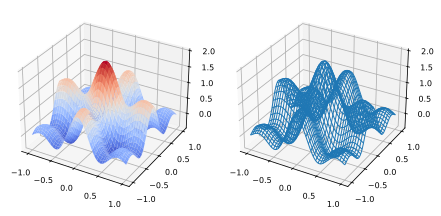

In [18]:
exercise_plot3d()

<a id='exercise_erlangen'></a> 
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064; display: block; break-after: avoid; page-break-after: avoid;">Exercise 5: Photo Manipulation (Erlangen)</strong>
<p style="color:#006064;">
In this exercise we study how one may represent and manipulate digital images using <code>matplotlib</code>. 
</p>
<ul style="color:#006064;">
    <li>First, import <code>matplotlib.image</code> as <code>mpimg</code>.</li>
    <li>Using <code>mpimg.imread</code>, load the photo <code>'./data/PCP_fig_erlangen.png'</code>, which shows the castle of the city of Erlangen (home of FAU). This results in an NumPy array of size <code>(274, 400, 3)</code>. Check this! While the first two dimensions specify the number of pixels in horizontal and vertical direction, the third dimension are the color channels of the RGB (red, green, blue) color space.</li>
    <li> Display the image using <code>plt.imshow</code>.</li>
    <li> Rotate the image by $180^\circ$ using the function <code>np.rot90</code>.</li>
    <li> Convert the color image into a black&ndash;with figure by summing over the channels. Furthermore, set <code>cmap='gray'</code> in <code>plt.imshow</code>.</li>
    <li> Try to extract edges, e.g., by applying <code>np.diff</code>.</li>
    <li> Be creative to further modify the image, e.g., by manipulating the channels and the changing colormap specified by <code>cmap</code>.  </li>
    <li> Save your modified images by using the command <code>mpimg.imsave('./output/PCP_fig_erlangen_mod.png', img_mod)</code></li>
</ul>
<p style="color:#006064;">
Picture by <a href="https://commons.wikimedia.org/wiki/User:Selby">Selby</a>. Licensed under <a href="https://creativecommons.org/licenses/by-sa/3.0/">CC BY-SA 3.0</a>.
</p>
</div>

In [19]:
# Your Solution

Size of image array (pixels, pixels, channels):  (274, 400, 3)


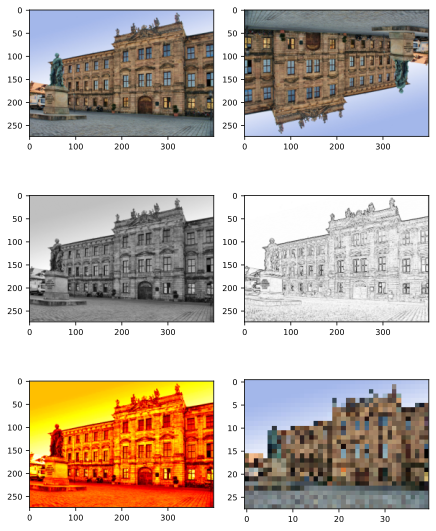

In [20]:
exercise_erlangen()

<div>
<a href="https://opensource.org/licenses/MIT"><img src="data_layout/PCP_License.png" width=100% style="float: right;" alt="PCP License"></a>
</div>